In [1]:
# laden der Packages
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sn

from scipy.stats import norm
from scipy.stats import binom
from scipy.stats import hypergeom
from scipy.stats import t
from scipy.stats import chi2

In [2]:
import warnings
warnings.filterwarnings("ignore")

# Stetige Verteilungen


### Ziele der Übung

- Zufallsvariablen und dessen Erwartungswerte
- Verteilungen pdf und cdf
- Stetige Verteilungen: Normalverteilung, t-Verteilung $\chi^2$ Verteilung

**Hilfestellung:**
- Informationen zur Normalverteilung in Python: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html
- Informationen zur t Verteilung in Python: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.t.html
- Informationen zur $\chi^2$ Verteilung in Python: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.chi2.html?highlight=chi2

## Aufgabe 1: Normalverteilung

Visualisiere in Python die pdf einer Normalverteilung mit 

- $\mu = \{3, 4, 5, 10\}$ und $\sigma = 0.5$
- $\mu = 5$ und $\sigma = \{0.1, 0.3, 0.5, 1\}$

was fällt dir auf?

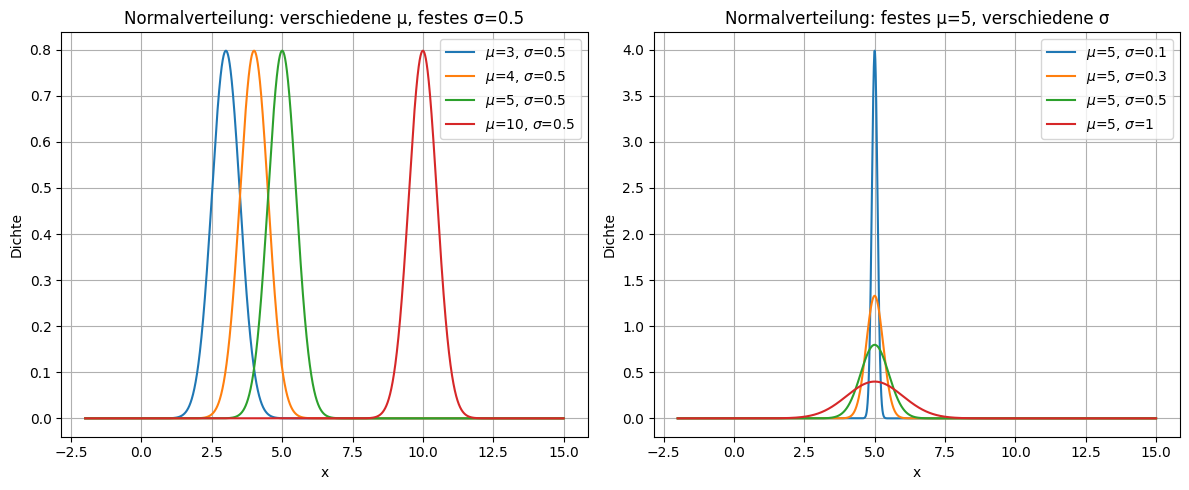

In [11]:
#PDF der Normalverteilung mit verschiedenen mu und sigma

mu = [3,4,5,10]
sigma = 0.5

mu_2 = 5
sigma_2 = [0.1,0.3,0.5,1]

#x-werte
x = np.linspace(-2, 15, 100000)

fig, axs = plt.subplots(1,2, figsize=(12,5))

ax = axs[0]
for val_mu in mu:
    pdf = norm.pdf(x, loc = val_mu, scale = sigma)
    ax.plot(x, pdf, label=f'$\mu$={val_mu}, $\sigma$={sigma}')
ax.set_xlabel('x')
ax.set_ylabel('Dichte')
ax.set_title('Normalverteilung: verschiedene μ, festes σ=0.5')
ax.legend()
ax.grid(True)

ax = axs[1]
for val_sigma in sigma_2:
    pdf = norm.pdf(x, loc = mu_2, scale = val_sigma)
    ax.plot(x, pdf, label=f'$\mu$={mu_2}, $\sigma$={val_sigma}')
ax.set_xlabel('x')
ax.set_ylabel('Dichte')
ax.set_title('Normalverteilung: festes μ=5, verschiedene σ')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()


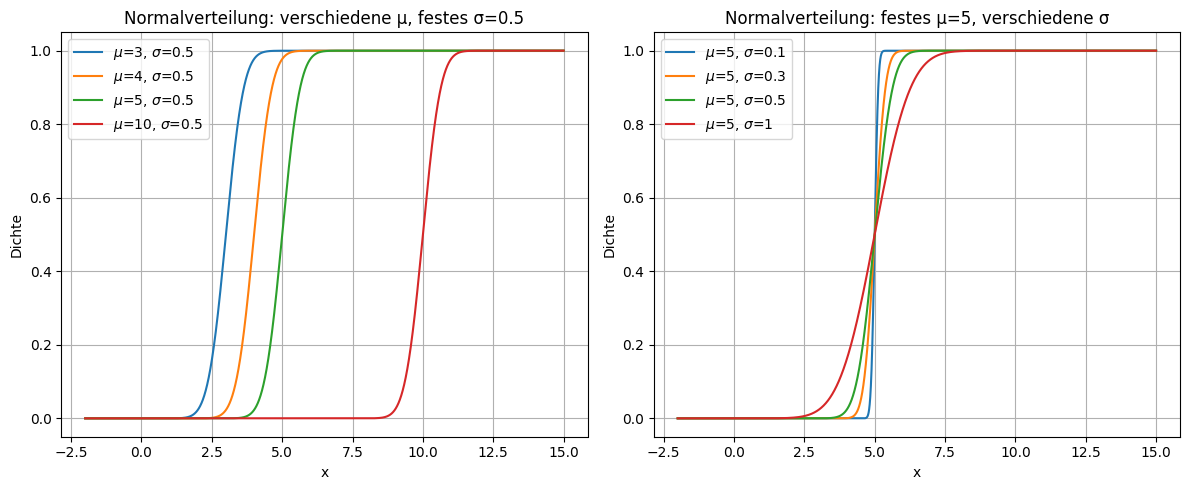

In [12]:
#CDF der Normalverteilung mit verschiedenen mu und sigma
mu = [3,4,5,10]
sigma = 0.5

mu_2 = 5
sigma_2 = [0.1,0.3,0.5,1]

#x-werte
x = np.linspace(-2, 15, 100000)

fig, axs = plt.subplots(1,2, figsize=(12,5))

ax = axs[0]
for val_mu in mu:
    pdf = norm.cdf(x, loc = val_mu, scale = sigma)
    ax.plot(x, pdf, label=f'$\mu$={val_mu}, $\sigma$={sigma}')
ax.set_xlabel('x')
ax.set_ylabel('Dichte')
ax.set_title('Normalverteilung: verschiedene μ, festes σ=0.5')
ax.legend()
ax.grid(True)

ax = axs[1]
for val_sigma in sigma_2:
    pdf = norm.cdf(x, loc = mu_2, scale = val_sigma)
    ax.plot(x, pdf, label=f'$\mu$={mu_2}, $\sigma$={val_sigma}')
ax.set_xlabel('x')
ax.set_ylabel('Dichte')
ax.set_title('Normalverteilung: festes μ=5, verschiedene σ')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()


## Aufgabe 2: Normalverteilung

In einem Werk für Kosmetika und Seife wird Gesichtswasser maschinell in Flaschen abgefüllt. Der alte Werkmeister weiß, dass die von der Maschine abgefüllten Mengen einen Erwartungswert von 145 ccm und eine Standardabweichung von 2 ccm aufweisen und
normalverteilt sind. 

a) Visualisiere pdf und cdf. 

b) Wie groß ist die Wahrscheinlichkeit, dass eine zufällig gewählte Flasche weniger als 145 ccm besitzt?

c) Wie groß ist die Wahrscheinlichkeit, dass eine zufällig gewählte Flasche mehr als 155 ccm besitzt?

d) Wie groß ist die Wahrscheinlichkeit, dass eine zufällig gewählte Flasche zwischen 150 ccm und 155 ccm besitzt?

e) Welches Maximalvolumen wird von 90% der Flaschen unterschritten?

f) Welches Minimalvolumen wird von 90% der Flaschen überschritten?

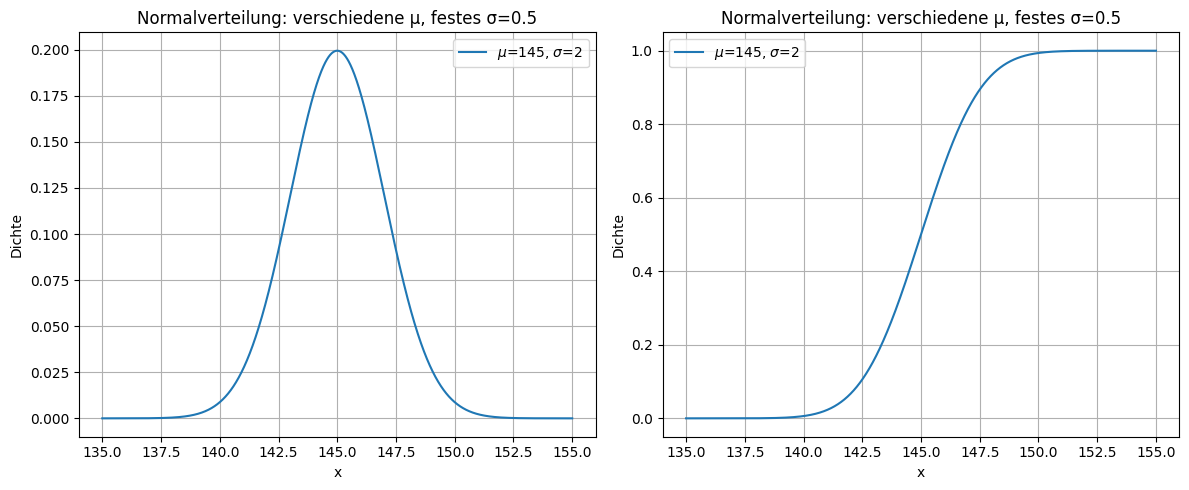

P(X <= 145) = 50.0000%
P(X >= 150) = 0.000028665%
P(150 <= X <= 155) = 0.6209%
90% der Flaschen haben höchstens 147.5631 ccm
90% der Flaschen haben mindestens 142.4369 ccm


In [27]:
#a)
mu = 145
sigma = 2

#x-werte
x = np.linspace(135, 155, 10000)

fig, axs = plt.subplots(1,2, figsize=(12,5))

ax = axs[0]
pdf = norm.pdf(x, loc = mu, scale = sigma)
ax.plot(x, pdf, label=f'$\mu$={mu}, $\sigma$={sigma}')
ax.set_xlabel('x')
ax.set_ylabel('Dichte')
ax.set_title('Normalverteilung: verschiedene μ, festes σ=0.5')
ax.legend()
ax.grid(True)

ax = axs[1]
pdf = norm.cdf(x, loc = mu, scale = sigma)
ax.plot(x, pdf, label=f'$\mu$={mu}, $\sigma$={sigma}')
ax.set_xlabel('x')
ax.set_ylabel('Dichte')
ax.set_title('Normalverteilung: verschiedene μ, festes σ=0.5')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

# b)c)d)
p_145 = norm.cdf(145, loc = mu, scale = sigma)*100
p_150 = norm.cdf(150, loc = mu, scale = sigma)*100
p_155 = norm.cdf(155, loc = mu, scale = sigma)*100

print(f'P(X <= 145) = {p_145:.4f}%')
print(f'P(X >= 150) = {100-p_155:.9f}%')
print(f'P(150 <= X <= 155) = {p_155 - p_150:.4f}%')

#e)f)
max_90 = norm.ppf(0.9, loc=mu, scale=sigma)
print(f'90% der Flaschen haben höchstens {max_90:.4f} ccm')

min_90 = norm.ppf(0.1, loc=mu, scale=sigma)
print(f'90% der Flaschen haben mindestens {min_90:.4f} ccm')

Ein unternehmen stellt Kugelschreiber her, die aus folgendne komponenten bestehen.
* Gewicht Schreibmine: N(2.5g, sigma = 0,2g)
* Gewicht Metallfeder: N(0.5g, sigma = 0.05g)
* Gewicht Kunstoffhülle: N(10g, sigma = 0.8g)
Das Gewicht in der einzelnen Komponenten ist unabhängung voneinander

a) Bestimme die Verteilung des Gesamtgewichts

b) Welches Gesamtgewicht wird von 15% der Kugelschreiber überschritten?

a) Gesamtgewicht: N(μ=13.00g, σ=0.8261g)
   Varianz: 0.6825 g²


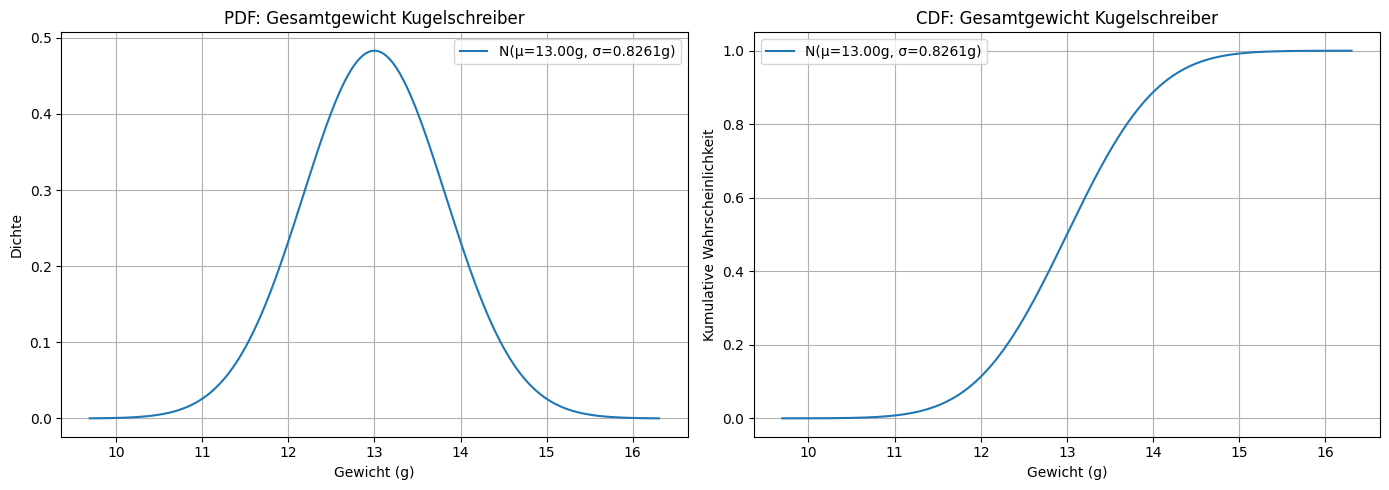


b) 15% der Kugelschreiber wiegen mehr als 13.8562g


In [28]:
# Gegebene Verteilungen der einzelnen Komponenten
mu_mine = 2.5
sigma_mine = 0.2

mu_feder = 0.5
sigma_feder = 0.05

mu_huelle = 10
sigma_huelle = 0.8

# a) Verteilung des Gesamtgewichts
# Bei unabhängigen Normalverteilungen addieren sich:
# - die Mittelwerte
# - die Varianzen (nicht die Standardabweichungen!)

mu_gesamt = mu_mine + mu_feder + mu_huelle
# Varianzen addieren
var_gesamt = sigma_mine**2 + sigma_feder**2 + sigma_huelle**2
# Standardabweichung ist Wurzel der Varianz
sigma_gesamt = np.sqrt(var_gesamt)

print(f'a) Gesamtgewicht: N(μ={mu_gesamt:.2f}g, σ={sigma_gesamt:.4f}g)')
print(f'   Varianz: {var_gesamt:.4f} g²')

# Visualisierung
x = np.linspace(mu_gesamt - 4*sigma_gesamt, mu_gesamt + 4*sigma_gesamt, 1000)
pdf = norm.pdf(x, loc=mu_gesamt, scale=sigma_gesamt)
cdf = norm.cdf(x, loc=mu_gesamt, scale=sigma_gesamt)

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

ax = axs[0]
ax.plot(x, pdf, label=f'N(μ={mu_gesamt:.2f}g, σ={sigma_gesamt:.4f}g)')
ax.set_xlabel('Gewicht (g)')
ax.set_ylabel('Dichte')
ax.set_title('PDF: Gesamtgewicht Kugelschreiber')
ax.legend()
ax.grid(True)

ax = axs[1]
ax.plot(x, cdf, label=f'N(μ={mu_gesamt:.2f}g, σ={sigma_gesamt:.4f}g)')
ax.set_xlabel('Gewicht (g)')
ax.set_ylabel('Kumulative Wahrscheinlichkeit')
ax.set_title('CDF: Gesamtgewicht Kugelschreiber')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

# b) Gesamtgewicht, das von 15% überschritten wird
# 15% überschreiten = 85% unterschreiten = 85%-Quantil
gewicht_85 = norm.ppf(0.85, loc=mu_gesamt, scale=sigma_gesamt)
print(f'\nb) 15% der Kugelschreiber wiegen mehr als {gewicht_85:.4f}g')

## Aufgabe 3: Student $t$-Verteilung


Visualisiere pdf und cdf einer Student $t$-Verteilung mit Freiheitsgraden $\nu \in  [1, 3, 5, 10, 20, 30, 50, 100]$

Berechne jeweils Erwartungswert, Standardabweichung, Schiefe und Kurtosis. Was fällt auf, wenn du es mit einer Standardnormalverteilung vergleichst? 

## Aufgabe 4: $\chi^2$-Verteilung


Visualisiere pdf und cdf einer $\chi^2$-Verteilung mit Freiheitsgraden $\nu \in  [2, 3, 5, 10, 20, 30]$ auf dem Intevall $0 \leq x \leq 50$. 

Berechne jeweils Erwartungswert, Standardabweichung, Schiefe und Kurtosis. Was fällt auf, wenn du es mit einer Normalverteilung vergleichst? 

## Aufgabe 5: Zentraler Grenzwertsatz

Schreibe dir in Python ein kleines Programm und generiere dir 10.000 mal jeweils 1000 Realisierungen einer $\chi^2$-verteilte Zufallsvariablen mit Parameter $k = 3$. Bestimme in jeder Schleife den Mittelwert und speichere ihn in einem Vektor. Am Ende hast du einen
Vektor mit 10.000 Mittelwerten. Schau dir dessen Dichtefunktion an. Was fällt dir auf?